# **Customer Churn Prediction – Business-Oriented Framework**

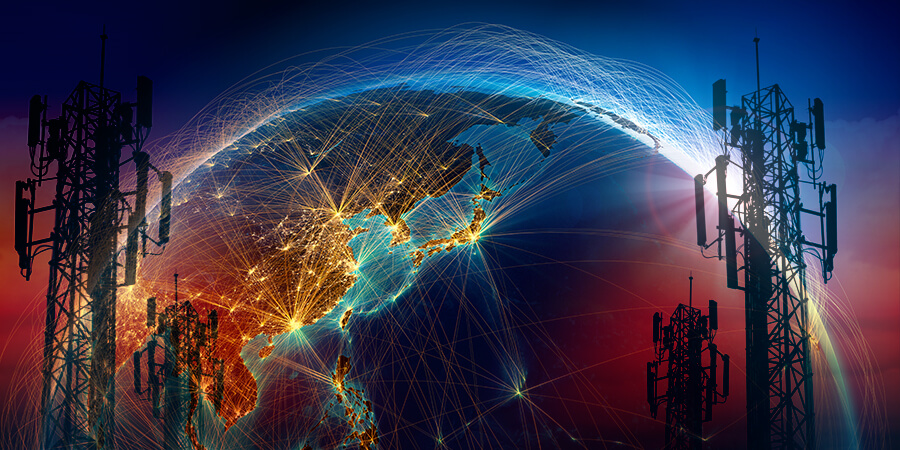

## **1. Project Objective**

Mục tiêu của dự án là xây dựng mô hình dự đoán khả năng rời bỏ của khách hàng (Customer Churn Prediction) nhằm hỗ trợ doanh nghiệp xác định khách hàng có nguy cơ churn cao và đưa ra chiến lược giữ chân phù hợp.

Tuy nhiên, bài toán không chỉ dừng lại ở việc dự đoán churn mà còn tập trung vào việc đánh giá giá trị kinh tế của từng khách hàng. Bằng cách kết hợp xác suất churn với Customer Value và Retention Cost, doanh nghiệp có thể tối ưu hóa quyết định giữ chân và nâng cao lợi nhuận.

Dự án hướng đến tư duy business-driven analytics, nơi mô hình không chỉ phục vụ dự đoán mà còn hỗ trợ ra quyết định kinh doanh thực tế.

## **2. Expected Outcome**

Kết quả mong đợi của dự án bao gồm:

Xác định các yếu tố quan trọng ảnh hưởng đến churn như tenure, MonthlyCharges, Contract, TechSupport, InternetService,...
Xây dựng mô hình Logistic Regression để dự đoán xác suất churn của khách hàng
Tối ưu threshold classification dựa trên Recall, F1-score và Expected Profit thay vì chỉ dùng Accuracy
Ước tính Customer Value để xác định khách hàng nào thực sự đáng để giữ chân
Đề xuất chiến lược retention phù hợp nhằm tối đa hóa lợi nhuận doanh nghiệp

Mục tiêu cuối cùng không phải là giảm churn bằng mọi giá, mà là giữ đúng khách hàng để tối ưu business value.

## **3. Table of Contents**

## 1. Business Understanding
Hiểu bài toán churn dưới góc nhìn business: không chỉ dự đoán ai sẽ rời bỏ, mà còn xác định khách hàng nào thực sự đáng để giữ chân dựa trên lợi nhuận kỳ vọng.



## 2. Data Understanding
Hiểu cấu trúc dataset, biến mục tiêu (Churn) và ý nghĩa của các biến như tenure, MonthlyCharges, Contract, TechSupport...



## 3. Data Cleaning
Kiểm tra kiểu dữ liệu, missing values, duplicate và xử lý dữ liệu để đảm bảo chất lượng trước khi modeling.



## 4. Exploratory Data Analysis (EDA)
Phân tích mối quan hệ giữa các biến với churn để tìm insight và hiểu hành vi khách hàng.



## 5. Data Preprocessing
Encoding biến categorical, scaling dữ liệu và chuẩn bị dữ liệu phù hợp cho Logistic Regression.



## 6. Logistic Regression Modeling
Xây dựng mô hình Logistic Regression để dự đoán xác suất churn và phân tích coefficients nhằm hiểu tác động của từng biến.



## 7. Cost-Sensitive Model Evaluation
Đánh giá mô hình bằng confusion matrix, recall, precision và phân tích trade-off giữa False Positive và False Negative dưới góc nhìn business cost.



## 8. Threshold Optimization
Tối ưu threshold dựa trên tổng business cost thay vì sử dụng threshold mặc định 0.50.



## 9. Customer Value Estimation
Ước tính giá trị khách hàng dựa trên MonthlyCharges và retention horizon nhằm hỗ trợ quyết định giữ chân.



## 10. Expected Profit Framework
Kết hợp churn probability, customer value và retention cost để xác định khách hàng nào mang lại expected profit dương.



## 11. Customer Segmentation
Phân nhóm khách hàng theo churn risk và customer value nhằm hỗ trợ chiến lược retention phù hợp.



## 12. Business Recommendations
Đưa ra chiến lược retention dựa trên expected profit và business impact thay vì giảm churn đại trà.




**Import Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Link Data : https://www.kaggle.com/code/farazrahman/telco-customer-churn-logisticregression/input

In [3]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### **Fix Type Data**

In [5]:
df = df.astype({col: 'string' for col in df.select_dtypes(include='object').columns})

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Binary
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [7]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


### **Check Missing Value**

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.drop(columns=[ 'customerID'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   string 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   string 
 7   InternetService   7043 non-null   string 
 8   OnlineSecurity    7043 non-null   string 
 9   OnlineBackup      7043 non-null   string 
 10  DeviceProtection  7043 non-null   string 
 11  TechSupport       7043 non-null   string 
 12  StreamingTV       7043 non-null   string 
 13  StreamingMovies   7043 non-null   string 
 14  Contract          7043 non-null   string 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   string 


### **Check Category Data**

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

In [11]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].astype('string').str.strip().str.lower()

### **Check Duplicate**

In [12]:
df.duplicated().sum()

np.int64(22)

### **Deleted Duplicate**

In [13]:
df = df.drop_duplicates()

### **Check Outliers**

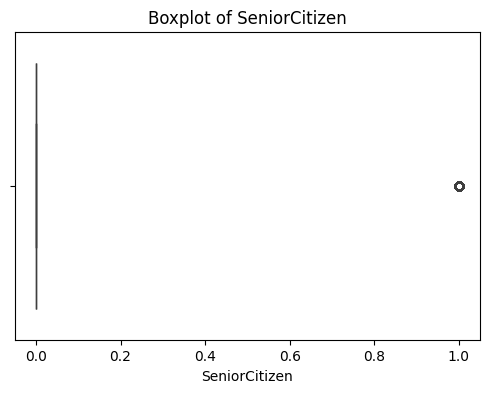

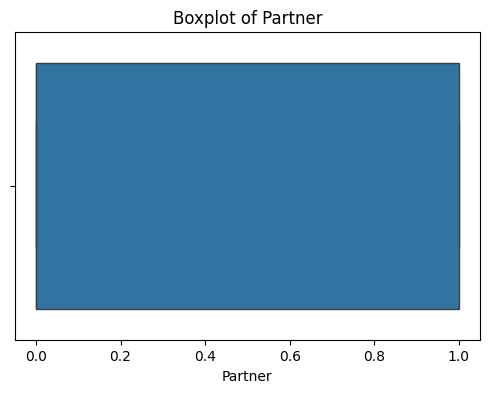

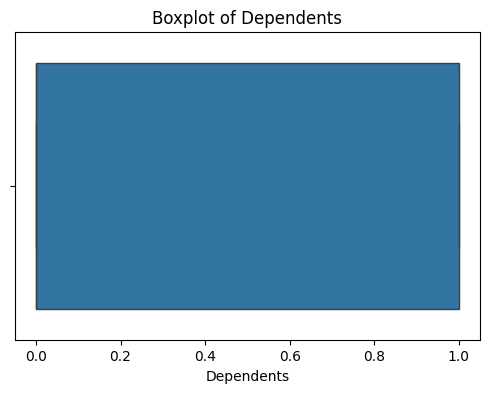

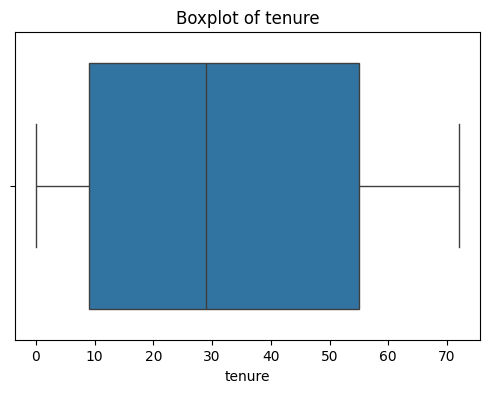

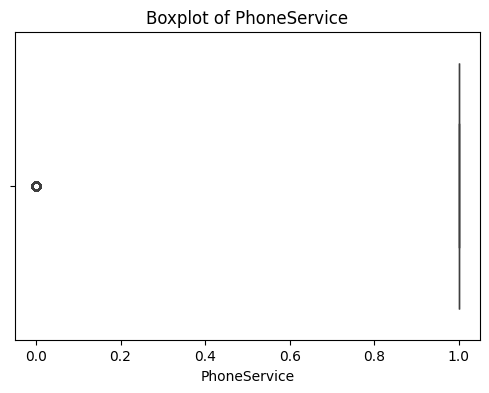

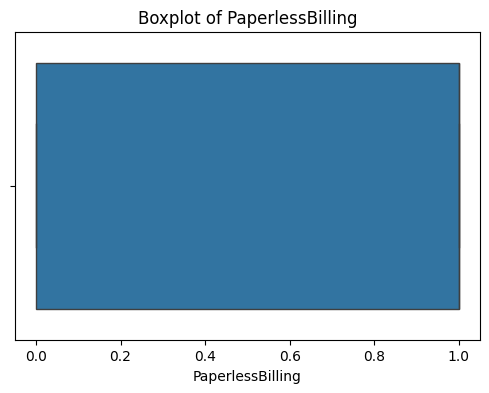

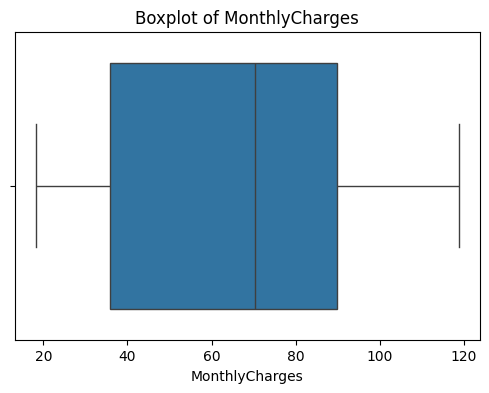

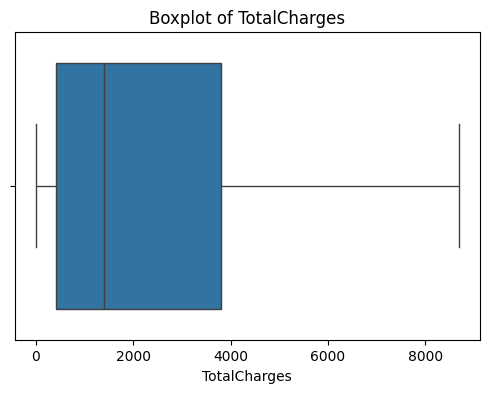

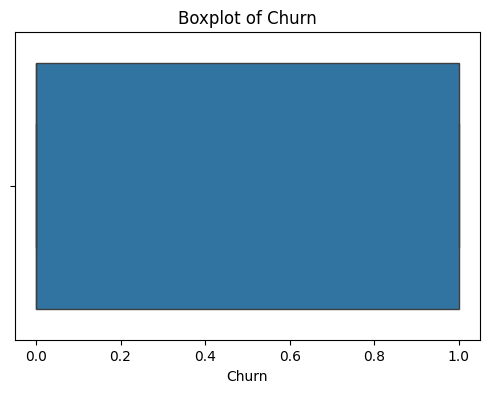

In [14]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [15]:
def check_outliers(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} outliers")

check_outliers(df)

SeniorCitizen: 1141 outliers
Partner: 0 outliers
Dependents: 0 outliers
tenure: 0 outliers
PhoneService: 682 outliers
PaperlessBilling: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers
Churn: 0 outliers


## **EDA (Exloratory Data Analysis)**

Churn là trạng thái khách hàng ngừng sử dụng dịch vụ và chính thức hủy hợp đồng với doanh nghiệp. Trong bộ dữ liệu Telco này, khách hàng được xem là churn khi họ đã chấm dứt dịch vụ trong tháng gần nhất (Churn = Yes), không phải chỉ tạm thời không sử dụng vài ngày.

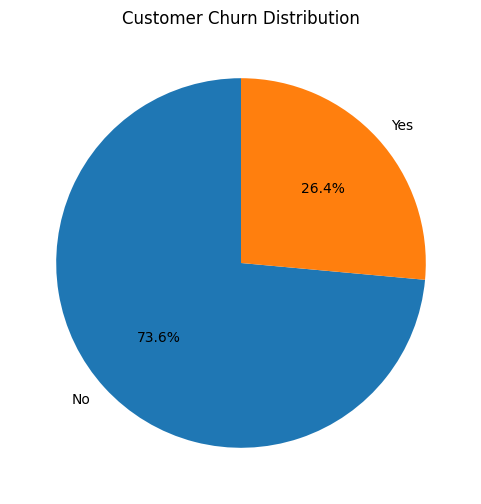

In [16]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['No', 'Yes'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Churn Distribution')
plt.show()

Từ biểu đồ có thể thấy tỷ lệ khách hàng không churn chiếm 73.6%, trong khi khách hàng churn chiếm 26.4%. Điều này cho thấy phần lớn khách hàng vẫn duy trì dịch vụ, tuy nhiên tỷ lệ churn vẫn khá đáng kể và có thể gây ảnh hưởng lớn đến doanh thu nếu không có chiến lược giữ chân phù hợp.

**Distribution of Monthly Charges**

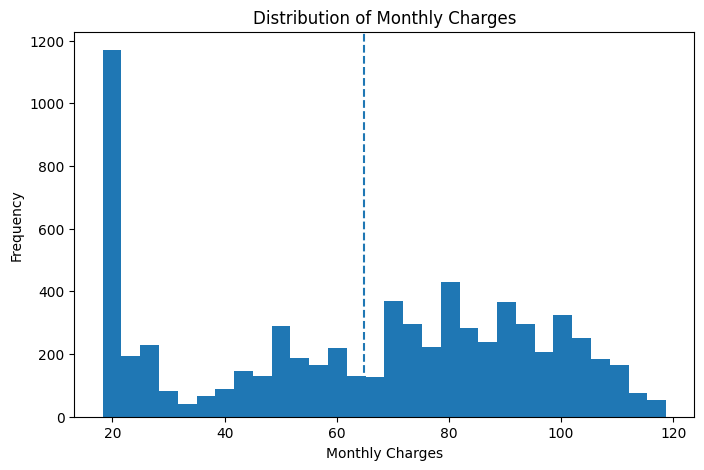

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['MonthlyCharges'], bins=30)

plt.axvline(df['MonthlyCharges'].mean(), linestyle='dashed')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.show()

**Total Charges by Churn**

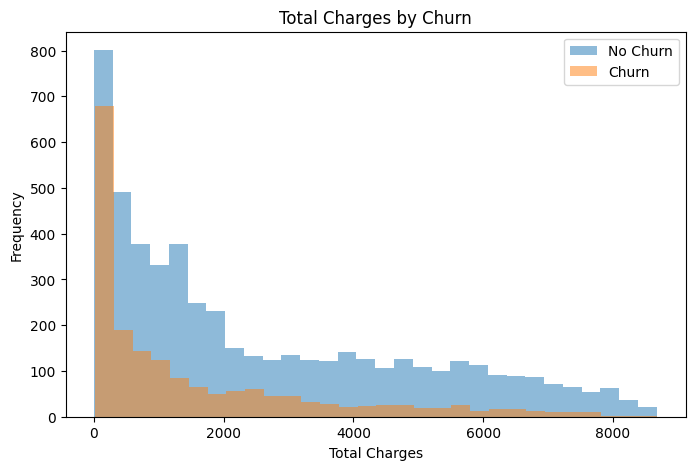

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Churn'] == 0]['TotalCharges'], bins=30, alpha=0.5, label='No Churn')
plt.hist(df[df['Churn'] == 1]['TotalCharges'], bins=30, alpha=0.5, label='Churn')
plt.legend()
plt.title('Total Charges by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')

plt.show()

**Quantitative**

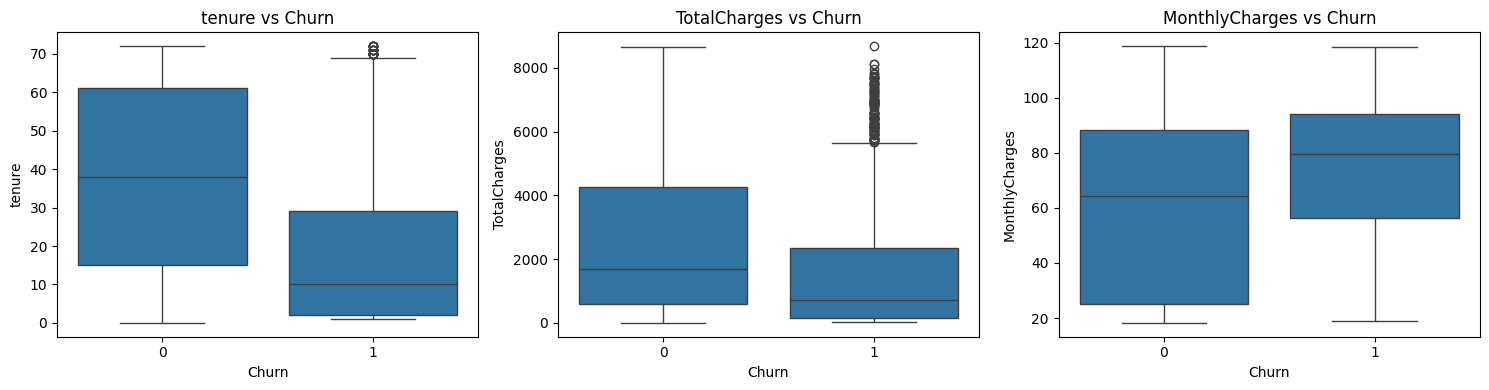

In [19]:
num_cols = ['tenure', 'TotalCharges', 'MonthlyCharges']
plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

**Tenure:**

Khách hàng churn có tenure thấp hơn rõ rệt so với nhóm không churn (median thấp). Điều này cho thấy khách hàng mới có xu hướng rời bỏ cao hơn, trong khi khách hàng gắn bó lâu dài có xu hướng ở lại.

**MonthlyCharges:**

Nhóm churn có MonthlyCharges cao hơn so với nhóm không churn. Điều này cho thấy chi phí hàng tháng cao có thể là một yếu tố khiến khách hàng dễ rời bỏ.

**TotalCharges:**

Khách hàng churn có TotalCharges thấp hơn, chủ yếu do tenure ngắn (chưa tích lũy nhiều chi phí). Điều này củng cố rằng churn thường xảy ra ở giai đoạn đầu vòng đời khách hàng.

=> Khách hàng mới (tenure thấp) + trả phí cao (MonthlyCharges cao) là nhóm có nguy cơ churn cao nhất và cần được ưu tiên trong chiến lược giữ chân.

**Qualitative**

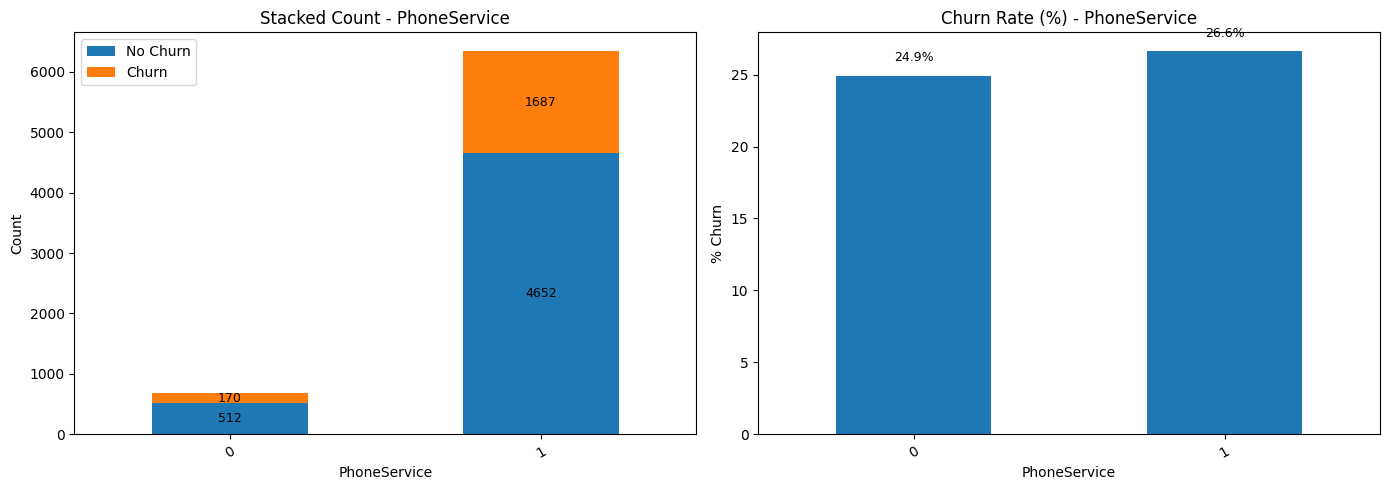

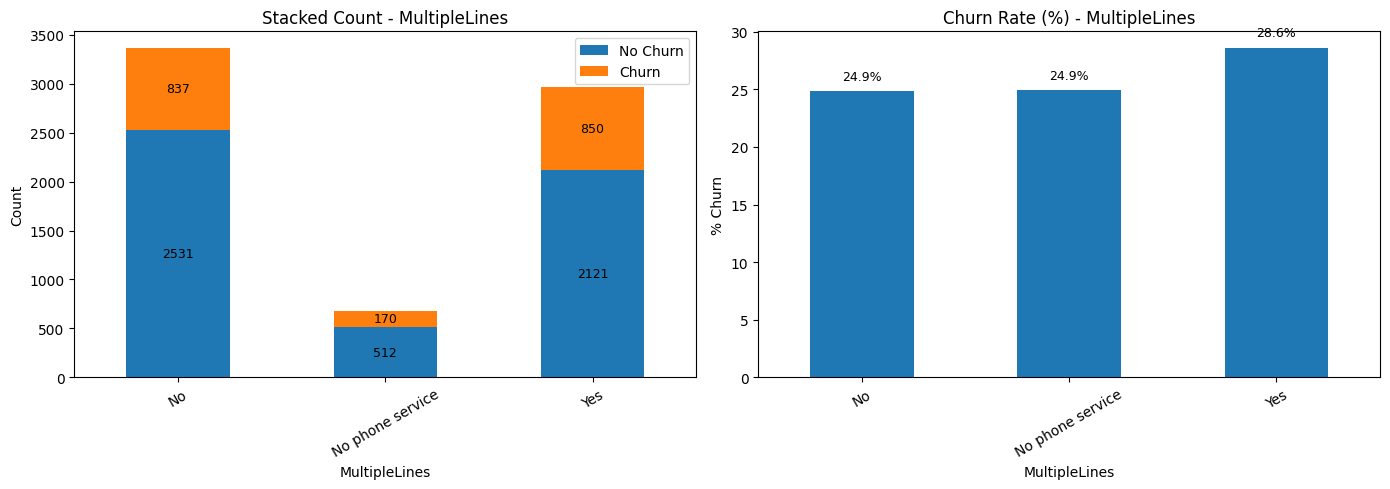

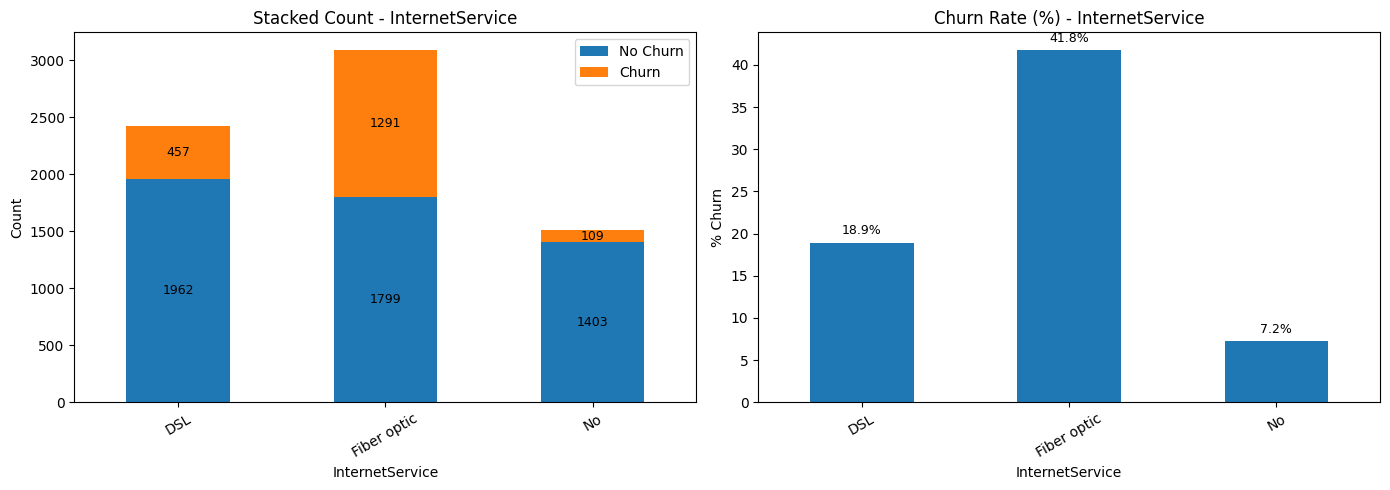

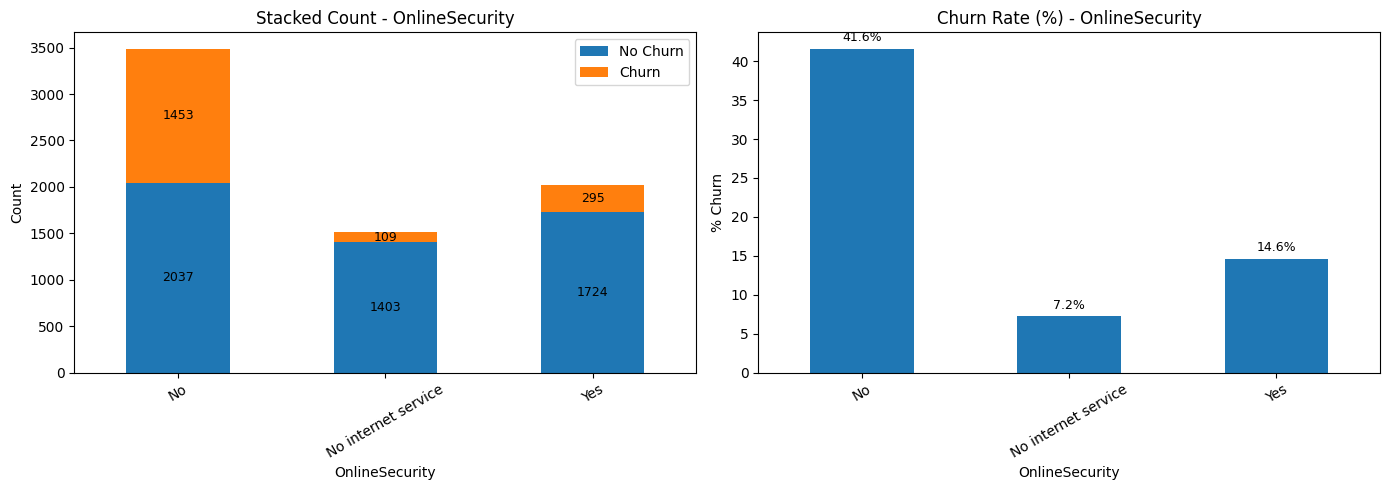

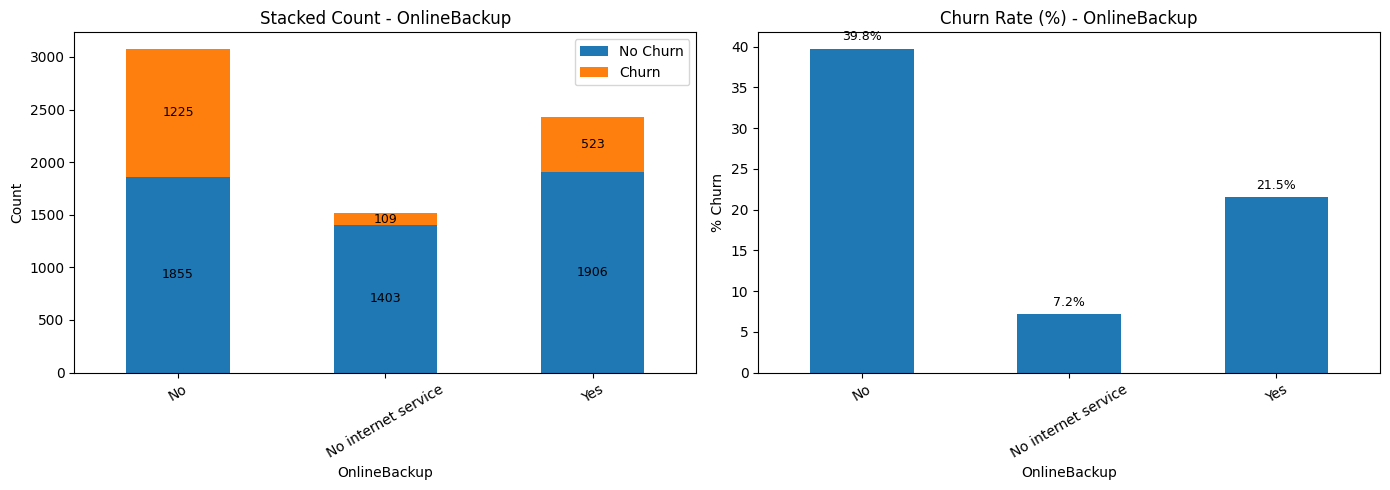

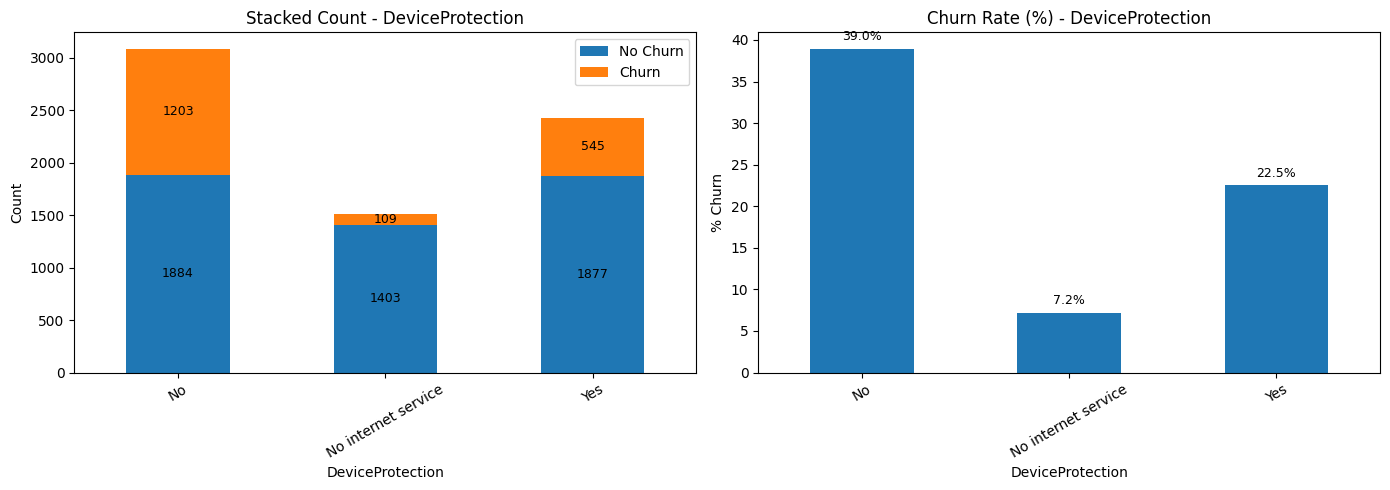

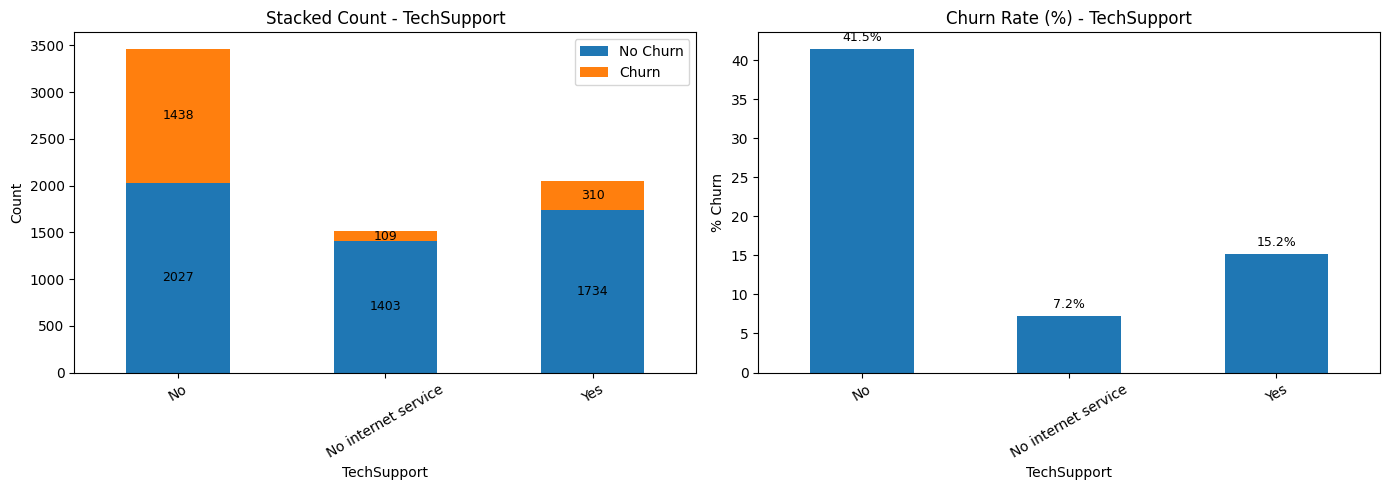

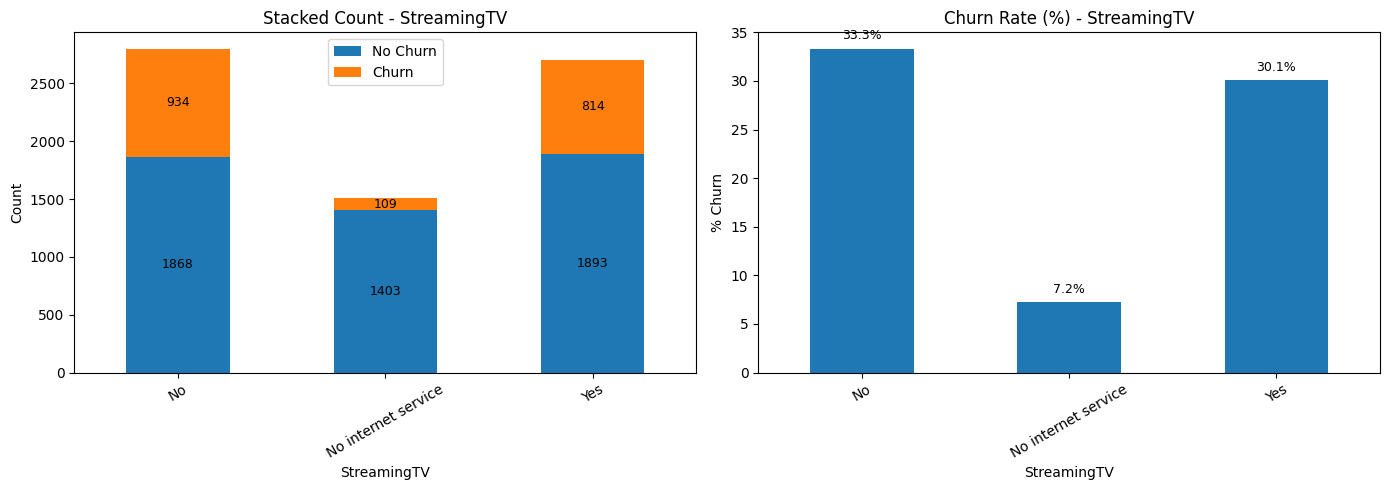

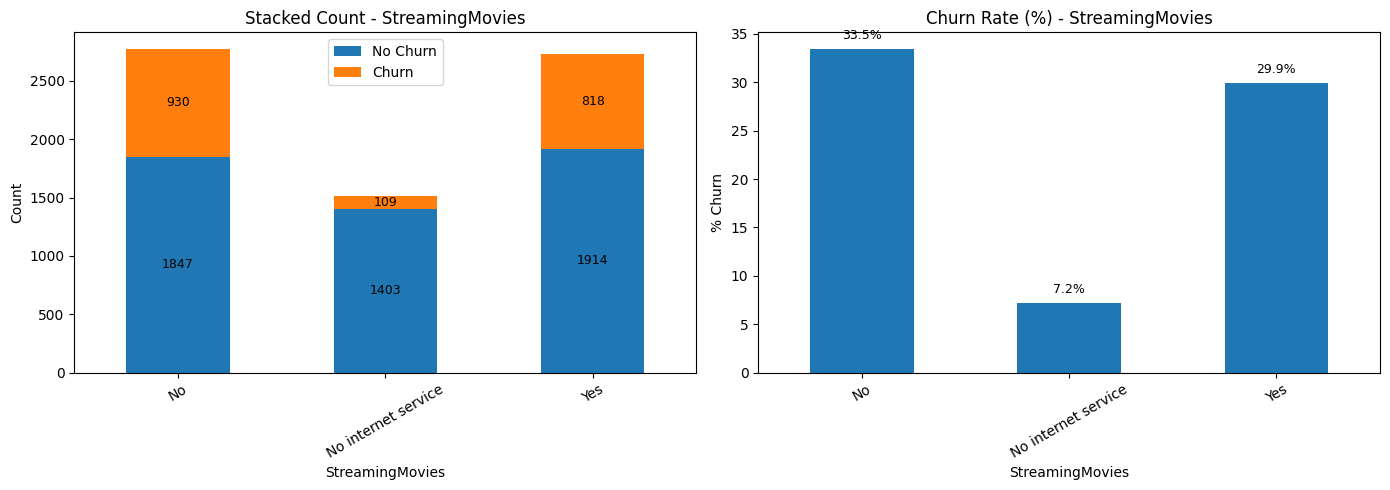

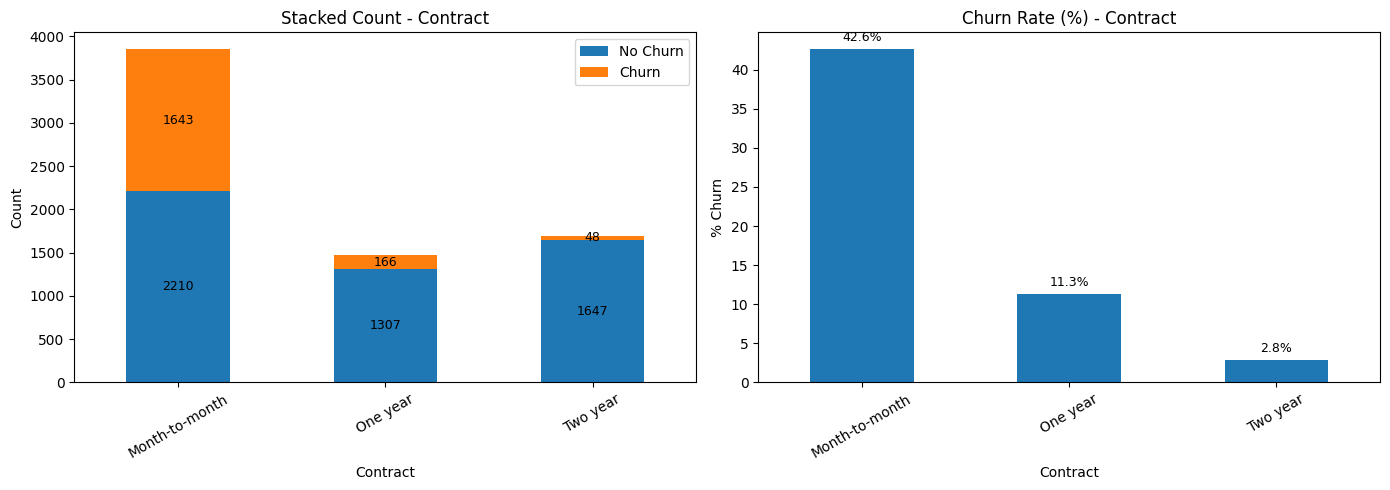

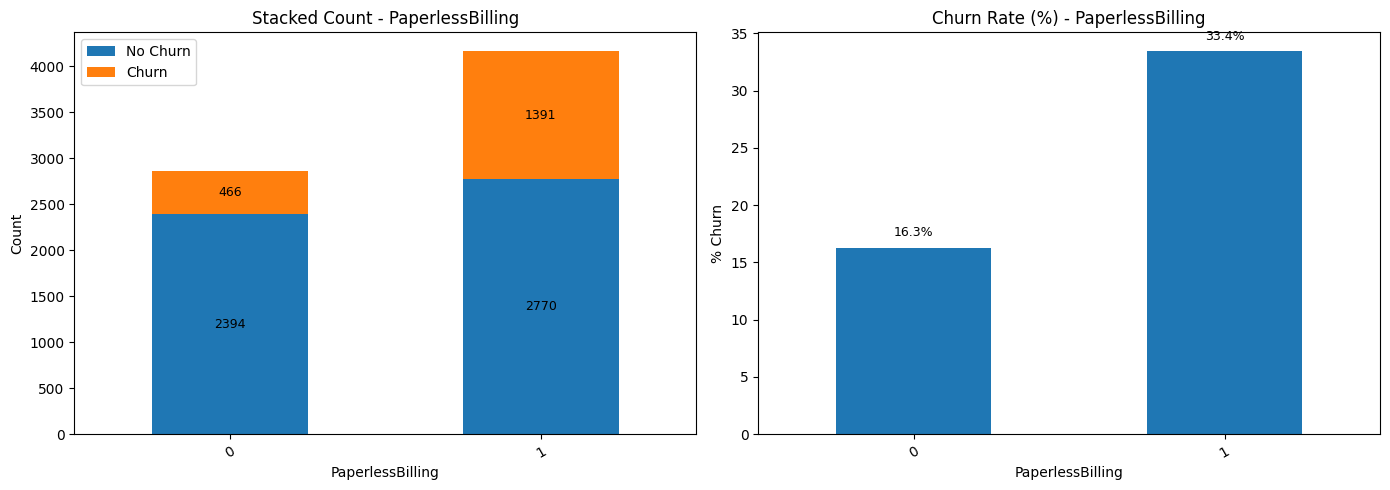

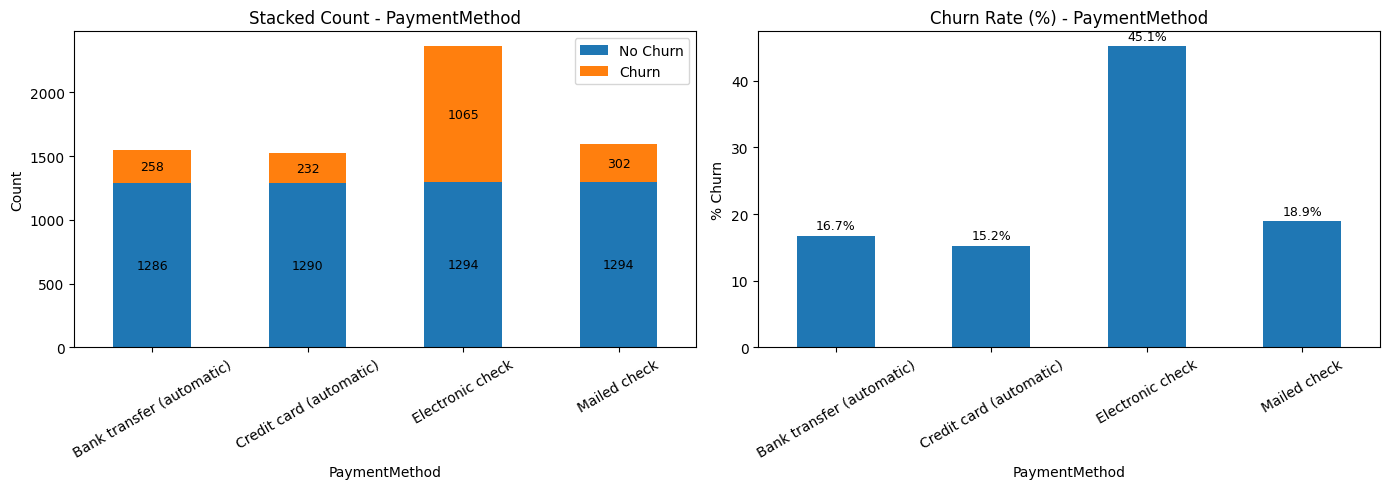

In [20]:
# Danh sách các cột categorical muốn phân tích
cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

# Nếu Churn đang là Yes/No thì convert về 0/1 trước
# Nếu đã là 0/1 thì bỏ đoạn này
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

for col in cols:
    plt.figure(figsize=(14, 5))

    # =========================
    # Plot 1: Stacked Count
    # =========================
    plt.subplot(1, 2, 1)

    count_data = pd.crosstab(df[col], df['Churn'])
    count_data.plot(
        kind='bar',
        stacked=True,
        ax=plt.gca()
    )

    plt.title(f'Stacked Count - {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.legend(['No Churn', 'Churn'])

    # Hiện số trên từng phần của stacked bar
    for i in range(len(count_data)):
        total = 0
        for j in range(len(count_data.columns)):
            value = count_data.iloc[i, j]
            plt.text(
                i,
                total + value / 2,
                str(value),
                ha='center',
                va='center',
                fontsize=9
            )
            total += value

    # =========================
    # Plot 2: Churn Rate (%)
    # =========================
    plt.subplot(1, 2, 2)

    churn_rate = df.groupby(col)['Churn'].mean() * 100
    ax2 = churn_rate.plot(kind='bar')

    plt.title(f'Churn Rate (%) - {col}')
    plt.xlabel(col)
    plt.ylabel('% Churn')
    plt.xticks(rotation=30)

    # Hiện % trên đầu cột
    for i, v in enumerate(churn_rate):
        ax2.text(
            i,
            v + 1,
            f'{v:.1f}%',
            ha='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

**INSIGHT**

**InternetService :**

Khách hàng sử dụng Fiber Optic có tỷ lệ churn cao nhất, lên tới 41.8%, cao hơn đáng kể so với nhóm sử dụng DSL (18.9%) và nhóm không sử dụng Internet Service (7.2%).

Điều này cho thấy mặc dù Fiber Optic thường đi kèm mức phí hàng tháng cao hơn và chất lượng dịch vụ tốt hơn, nhưng khách hàng trong nhóm này lại có xu hướng rời bỏ nhiều hơn. Nguyên nhân có thể đến từ giá cước cao, kỳ vọng dịch vụ lớn hơn hoặc mức độ cạnh tranh mạnh từ các nhà cung cấp khác.

Đây là một tín hiệu quan trọng vì nhóm Fiber Optic thường mang lại doanh thu cao, nên việc churn ở nhóm này có tác động lớn đến lợi nhuận doanh nghiệp và cần được ưu tiên trong chiến lược giữ chân khách hàng

**PhoneService :**

Tỷ lệ churn giữa hai nhóm PhoneService = Yes (26.6%) và No (24.9%) gần như không khác biệt đáng kể, dù số lượng khách có PhoneService chiếm đa số.

Điều này cho thấy PhoneService không phải là yếu tố ảnh hưởng mạnh đến churn, và sự khác biệt nhỏ có thể đến từ các yếu tố khác như InternetService hoặc MonthlyCharges hơn là bản thân PhoneService.

Churn Probability and MonthlyCharges

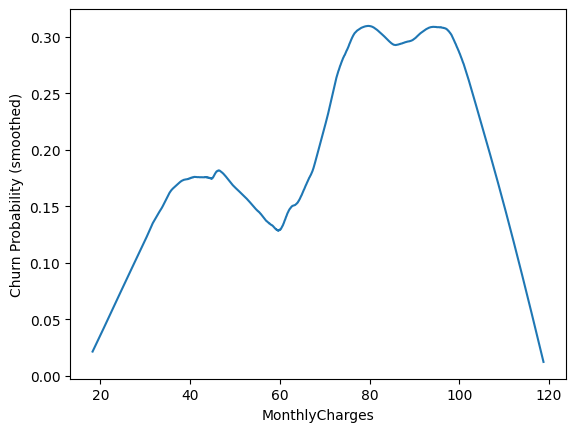

In [21]:
lowess = sm.nonparametric.lowess
z = lowess(df['Churn'], df['MonthlyCharges'], frac=0.3)

plt.plot(z[:,0], z[:,1])
plt.xlabel("MonthlyCharges")
plt.ylabel("Churn Probability (smoothed)")
plt.show()

>Xác suất rời bỏ (churn probability) thể hiện một mối quan hệ phi tuyến tính với Chi phí hàng tháng (MonthlyCharges).

>Trong khoảng từ 20–40, tỷ lệ rời bỏ tăng dần nhưng vẫn ở mức tương đối thấp, cho thấy nhóm khách hàng chi trả thấp có rủi ro rời bỏ thấp hơn. Trong khoảng từ 40–60, xu hướng này trở nên kém ổn định hơn với các biến động nhẹ, gợi ý đây là một vùng hành vi mang tính chuyển giao. Trong khoảng từ 60–90, tỷ lệ rời bỏ tăng mạnh và đạt đỉnh, đại diện cho phân khúc có rủi ro cao nhất. Vượt qua mốc 90+, tỷ lệ rời bỏ bắt đầu giảm xuống, có khả năng chỉ ra rằng những khách hàng chi trả cao hơn sẽ trung thành hơn hoặc có mô hình sử dụng ổn định hơn.

>Mối quan hệ này gợi ý một hiệu ứng ngưỡng (threshold effect) tiềm ẩn, nơi rủi ro rời bỏ tăng lên đáng kể khi vượt qua một mức Chi phí hàng tháng nhất định (~60), đánh dấu một vùng nhạy cảm về giá (pricing sensitivity zone)

**Churn Probability and Tenure**

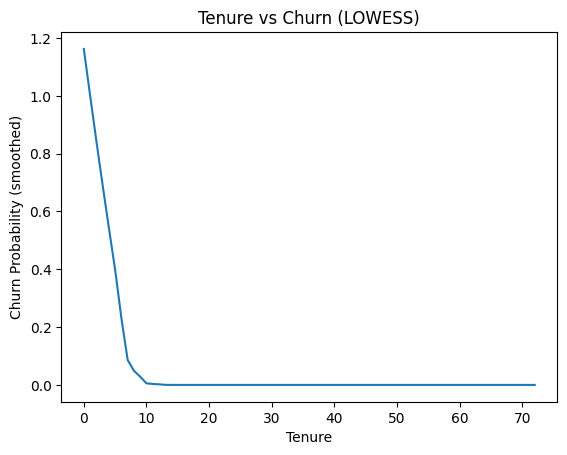

In [22]:
lowess = sm.nonparametric.lowess
z = lowess(df['Churn'], df['tenure'], frac=0.3)
plt.plot(z[:,0], z[:,1])
plt.xlabel("Tenure")
plt.ylabel("Churn Probability (smoothed)")
plt.title("Tenure vs Churn (LOWESS)")
plt.show()

>Tenure càng dài thì khả năng churn giảm những ở mức 10 tháng thì mối quan hệ dừng lại

Check data again

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### **One Hot Encoding**

In [24]:
# 1. Encode Contract
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# 2. One-hot các cột nominal
nominal_cols = [
    'gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

## **Correlation**

In [25]:
selected_cols = [
    'PaymentMethod_Electronic check',
    'StreamingMovies_Yes',
    'StreamingTV_Yes',
    'TechSupport_Yes',
    'DeviceProtection_Yes',
    'OnlineBackup_Yes',
    'InternetService_Fiber optic',
    'MultipleLines_Yes',
    'gender_Male',
    'SeniorCitizen',
    'Partner',
    'Contract',
    'Dependents',
    'tenure',
    'PhoneService',
    'MonthlyCharges',
    'PaperlessBilling',
    'TotalCharges',
    'Churn'
]

In [26]:
# convert boolean → int
bool_cols = df.select_dtypes(include='boolean').columns
df[bool_cols] = df[bool_cols].astype(int)

In [27]:
corr_selected = df[selected_cols].corr()

### **HeatMap Correlation**

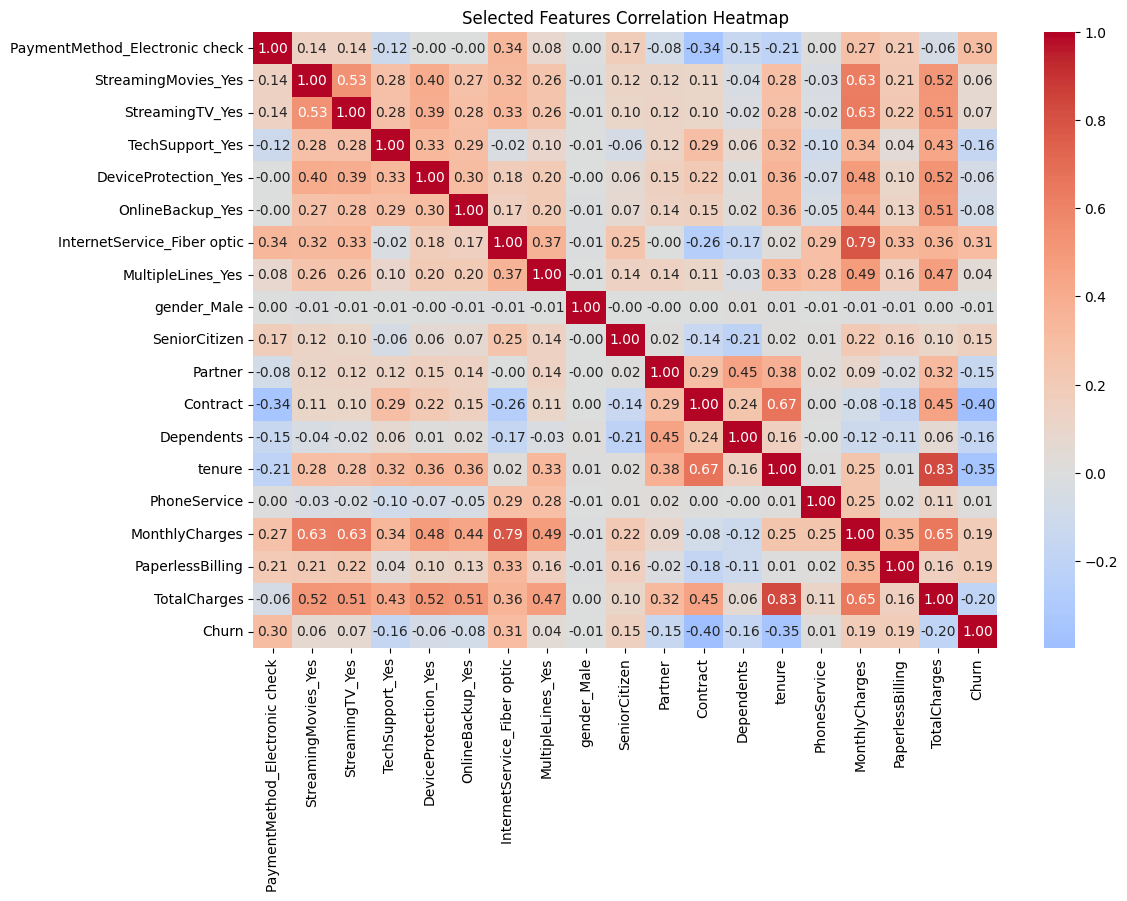

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_selected,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title('Selected Features Correlation Heatmap')
plt.show()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7021 non-null   int64  
 1   Partner                                7021 non-null   int64  
 2   Dependents                             7021 non-null   int64  
 3   tenure                                 7021 non-null   int64  
 4   PhoneService                           7021 non-null   int64  
 5   Contract                               7021 non-null   int64  
 6   PaperlessBilling                       7021 non-null   int64  
 7   MonthlyCharges                         7021 non-null   float64
 8   TotalCharges                           7021 non-null   float64
 9   Churn                                  7021 non-null   int64  
 10  gender_Male                            7021 non-null   int64  
 11  MultipleL

In [30]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,1,0,56.95,1889.50,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,2,1,0,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,1,0,42.30,1840.75,0,...,1,0,1,0,0,0,0,0,0,0
4,0,0,0,2,1,0,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


----

## **MACHINE LEARNING**

### **Build Model**

In [31]:
import statsmodels.api as sm
X_sm = df[[
     'PaymentMethod_Electronic check',
     'TechSupport_Yes',
    'DeviceProtection_Yes',
    'OnlineBackup_Yes',
     'MultipleLines_Yes',
    'MonthlyCharges',
    'SeniorCitizen',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling',
]]
X_sm = sm.add_constant(X_sm)
y = df['Churn']
model_sm = sm.Logit(y, X_sm).fit()
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.425595
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7021
Model:                          Logit   Df Residuals:                     7009
Method:                           MLE   Df Model:                           11
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.2633
Time:                        04:41:13   Log-Likelihood:                -2988.1
converged:                       True   LL-Null:                       -4056.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.2573      0.124    -10.167     

**Z core Scaler**

In [32]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


cols = [
    'PaymentMethod_Electronic check',
    'TechSupport_Yes',
    'DeviceProtection_Yes',
    'OnlineBackup_Yes',
    'MultipleLines_Yes',
    'MonthlyCharges',
    'SeniorCitizen',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling'
]

X_scaled = df[cols].copy()
num_cols = ['MonthlyCharges', 'tenure']

scaler = StandardScaler()

X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])


# 🔹 add constant
X_scaled = sm.add_constant(X_scaled)

y = df['Churn']

model_sm = sm.Logit(y, X_scaled).fit()
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.425595
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7021
Model:                          Logit   Df Residuals:                     7009
Method:                           MLE   Df Model:                           11
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.2633
Time:                        04:41:13   Log-Likelihood:                -2988.1
converged:                       True   LL-Null:                       -4056.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.5916      0.151     -3.927     

**MinMaxScaler**

In [33]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

X_scaled = df[cols].copy()
scaler = MinMaxScaler()

X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

X_scaled = sm.add_constant(X_scaled)

model_sm = sm.Logit(y, X_scaled).fit()
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.425595
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7021
Model:                          Logit   Df Residuals:                     7009
Method:                           MLE   Df Model:                           11
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.2633
Time:                        04:41:13   Log-Likelihood:                -2988.1
converged:                       True   LL-Null:                       -4056.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.6392      0.120     -5.323     

-----

### **Build Model to Predict**

In [34]:
 X = df[[
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'Contract',
    'PaperlessBilling',
    'MonthlyCharges',
    'TotalCharges',
    'gender_Male',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes',
    'PaymentMethod_Electronic check'
]]
y = df['Churn']

### **Split Dataset**

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [37]:
y_prob = model.predict_proba(X_test)[:, 1]

In [38]:

X_test['churn_prob'] = y_prob

In [39]:
y_pred = (y_prob > 0.15).astype(int)

In [40]:
print(y_prob[:10])
print(y_pred[:10])

[0.63113525 0.25176679 0.08156256 0.00400306 0.39878677 0.03222766
 0.00490944 0.00582011 0.28257266 0.01770073]
[1 1 0 0 1 0 0 0 1 0]


In [41]:
result = X_test.copy()
result['actual'] = y_test.values
result['churn_prob'] = y_prob
result['predicted'] = y_pred

print(result.head(10))

      SeniorCitizen  Partner  Dependents  tenure  PhoneService  Contract  \
3918              0        1           1      20             1         0   
2467              0        1           1      49             1         1   
2885              1        0           0      67             1         2   
3770              0        1           0      57             1         2   
3753              0        0           0       1             0         0   
4493              0        0           1      18             1         2   
2178              0        1           0      53             1         2   
2481              1        1           0      61             1         2   
1569              0        1           1      15             1         0   
1611              0        1           0      72             1         2   

      PaperlessBilling  MonthlyCharges  TotalCharges  gender_Male  ...  \
3918                 1           90.20       1776.55            1  ...   
2467           

In [42]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
baseline = y_test.value_counts(normalize=True).max()
print(f"Baseline accuracy (majority class): {baseline:.3f}")
print(f"Model vs Baseline: +{acc - baseline:.3f}")

Accuracy: 0.6647686832740214
Baseline accuracy (majority class): 0.749
Model vs Baseline: +-0.085


### **CROSS VALIDATION**

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)
scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
print("Accuracy từng fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy từng fold: [0.79231863 0.81623932 0.8005698  0.81481481 0.79059829 0.7977208
 0.81481481 0.8005698  0.7991453  0.80769231]
Mean accuracy: 0.8034483876589139


> CV accuracy (0.803) cao hơn test accuracy (0.66) do CV được chạy trên unscaled data. Test accuracy là con số đáng tin hơn để report

### CONFUSION MATRIX

In [44]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[605 448]
 [ 23 329]]


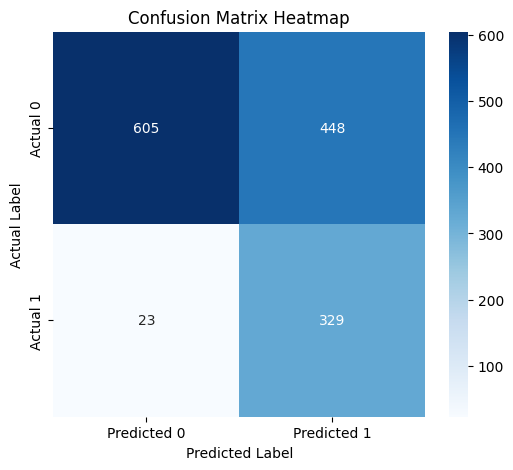

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.57      0.72      1053
           1       0.42      0.93      0.58       352

    accuracy                           0.66      1405
   macro avg       0.69      0.75      0.65      1405
weighted avg       0.83      0.66      0.69      1405



----

### **Chi phí để tìm một khách hàng mới là 100 và Chi phí đê giữ chân khách hàng là 20**

In [47]:
COST_FN = 100 # Chi phí tìm một khách hàng mới
COST_FP = 20 # Chi phí giữ chân khách hàng

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (fn * COST_FN) + (fp * COST_FP)

    results.append({
        "threshold": round(thresh, 2),
        "recall":    round(tp / (tp + fn), 3),
        "precision": round(tp / (tp + fp), 3),
        "FN":        fn,
        "FP":        fp,
        "total_cost": total_cost
    })

df_results = pd.DataFrame(results)
print(df_results)

    threshold  recall  precision   FN   FP  total_cost
0        0.10   0.957      0.389   15  530       12100
1        0.15   0.935      0.423   23  448       11260
2        0.20   0.886      0.444   40  391       11820
3        0.25   0.838      0.479   57  321       12120
4        0.30   0.776      0.510   79  262       13140
5        0.35   0.710      0.533  102  219       14580
6        0.40   0.670      0.553  116  191       15420
7        0.45   0.619      0.578  134  159       16580
8        0.50   0.548      0.594  159  132       18540
9        0.55   0.460      0.633  190   94       20880
10       0.60   0.381      0.694  218   59       22980
11       0.65   0.287      0.706  251   42       25940
12       0.70   0.188      0.750  286   22       29040
13       0.75   0.085      0.769  322    9       32380
14       0.80   0.031      1.000  341    0       34100
15       0.85   0.006      1.000  350    0       35000


In [49]:
best = df_results.loc[df_results["total_cost"].idxmin()]
print(f"\nThreshold tối ưu: {best['threshold']}")
print(f"Total cost thấp nhất: {best['total_cost']}")
print(f"Recall: {best['recall']} | Precision: {best['precision']}")
print(f"FN (bỏ sót): {best['FN']} | FP (giữ nhầm): {best['FP']}")


Threshold tối ưu: 0.15
Total cost thấp nhất: 11260.0
Recall: 0.935 | Precision: 0.423
FN (bỏ sót): 23.0 | FP (giữ nhầm): 448.0


>Threshold 0.15 được chọn vì đây là điểm có total_cost thấp nhất (11,260), với Recall = 0.935 và FP = 448. Tại ngưỡng này, mô hình chỉ bỏ sót 23 khách hàng thực sự churn (FN) — mỗi trường hợp bỏ sót tốn  100  để tìm khách mới.
 Trong khi đó, 448 trường hợp giữ nhầm (FP) chỉ tốn 20/người — chi phí thấp và chấp nhận được. Vì vậy, ưu tiên recall cao hơn precision phù hợp với business goal: không bỏ sót churner có giá trị cao.

----

------

#### Expected Profit Framework & Retention Decision

In [50]:
RETENTION_MONTHS = 3
RETENTION_COST = 20  # $20/month

result['customer_value'] = result['MonthlyCharges'] * RETENTION_MONTHS
result['expected_profit'] = (
    result['churn_prob'] * result['customer_value'] - (RETENTION_COST * RETENTION_MONTHS)
)
result['should_retain'] = result['expected_profit'] > 0
print(f"Số khách nên giữ: {result['should_retain'].sum()}")
print(f"Số khách không cần đầu tư: {(~result['should_retain']).sum()}")

Số khách nên giữ: 512
Số khách không cần đầu tư: 893


#### Value-Driven Customer Segmentation

In [51]:
# Phân nhóm khách hàng
value_median = result['customer_value'].median()

result['segment'] = 'Low Risk - Low Value'
result.loc[(result['churn_prob'] >= 0.3) & (result['customer_value'] >= value_median), 'segment'] = 'High Risk - High Value'
result.loc[(result['churn_prob'] >= 0.3) & (result['customer_value'] < value_median), 'segment'] = 'High Risk - Low Value'
result.loc[(result['churn_prob'] < 0.3) & (result['customer_value'] >= value_median), 'segment'] = 'Low Risk - High Value'

print(result['segment'].value_counts())

segment
Low Risk - Low Value      534
High Risk - High Value    367
Low Risk - High Value     336
High Risk - Low Value     168
Name: count, dtype: int64


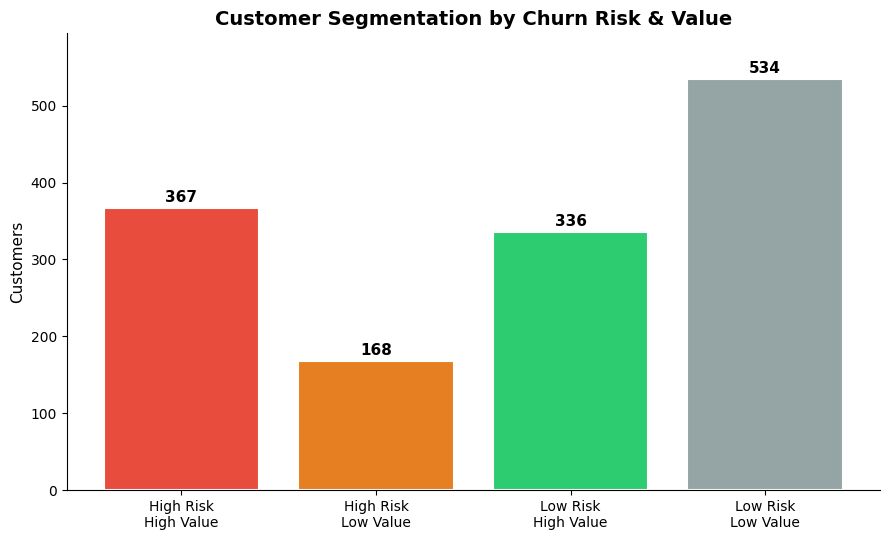

In [52]:

segments = [
    'High Risk\nHigh Value',
    'High Risk\nLow Value',
    'Low Risk\nHigh Value',
    'Low Risk\nLow Value'
]

counts = [367, 168, 336, 534]

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#95a5a6']

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    segments,
    counts,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# value labels
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 8,
        f'{count}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'Customer Segmentation by Churn Risk & Value',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel('Customers', fontsize=11)

ax.set_ylim(0, max(counts) + 60)

# clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

> Với retention cost $60  ( 3  tháng  × $20), chỉ 512/1,405 khách hàng có expected profit dương — tức là đáng đầu tư giữ chân. 893 khách còn lại không sinh lời ở mức chi phí này, chủ yếu do MonthlyCharges thấp hoặc xác suất churn không đủ cao để bù đắp chi phí bỏ ra.
Nhóm cần ưu tiên nhất là High Risk – High Value (367 khách) — vừa có nguy cơ rời bỏ cao vừa có giá trị đủ lớn để justify retention investment. Ngược lại, nhóm High Risk – Low Value (168 khách) dù nguy cơ cao nhưng không đáng can thiệp ở cấu trúc chi phí hiện tại.
Điều này cho thấy không phải cứ có nguy cơ churn là nên giữ — quyết định phải dựa trên expected profit, không phải xác suất churn đơn thuần.